## 1. Installation and imports

We start by importing all our libraries needed for this notebook. We also check the version of Python and PyTorch, and we initialize the device to be used (CPU or GPU).

In [13]:
# import statements for python, torch and companion libraries and your own modules
import torch
import os
import platform
import numpy as np
import random

from dotenv import load_dotenv
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm

load_dotenv()

# device initialization
device_name = os.getenv("DEVICE", "")
DEVICE = torch.device(
    device_name) if device_name else (
    torch.accelerator.current_accelerator()) if (
    torch.accelerator.is_available()) else (
    torch.device("cpu"))

print("Python :", platform.python_version())
print("PyTorch :", torch.__version__)
print("Device used :", DEVICE)

Python : 3.13.3
PyTorch : 2.14.0+cu132
Device used : cuda


Potentiel import supp à supprimer plus tard

In [16]:
import json, time, copy, platform, math
from collections import Counter

import pandas as pd
import matplotlib.pyplot as plt

import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision
from torchvision import transforms, models

C:\Users\theof\PycharmProjects\iav\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration

In this section, we will define the configuration parameters for our experiment. We start by defining the paths to the data and output directories. We also define some hyperparameters for training, such as the number of epochs, batch size, and learning rate. We also set a random seed for reproducibility and define a quick run option to limit the number of images processed for testing purposes.

In [8]:
# Defining global variables for data directories
DATA_ROOT = Path(os.getenv("DATA_ROOT", "/opt/iav/labs/data"))
DATA_ROOT = DATA_ROOT / "ms-coco"
IMAGE_DIR = DATA_ROOT / "images/train"
LABEL_DIR = DATA_ROOT / "labels/train"

# Defining global variables for output directories
OUTPUT_DIR = Path(os.getenv("JSON_PATH", "submission.json"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# TODO : check if all variables are defined
SEED = 30
EPOCHS = 10
BATCH_SIZE = 32
NUM_WORKERS = min(8, os.cpu_count() or 1)
IMAGE_SIZE = 224
PATIENCE = 3
VAL_FRACTION = 0.15

# For a quick run, you can set QUICK_RUN to True and limit the number of images processed
QUICK_RUN = False
QUICK_MAX_IMAGES = 5000
PIN_MEMORY = DEVICE.type == "cuda"


# Function to set random seed for reproducibility
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = (DEVICE.type == "cuda")


set_seed()

print("Images :", IMAGE_DIR.resolve())
print("Annotations :", LABEL_DIR.resolve())
print("Outputs :", OUTPUT_DIR.resolve())

Images : C:\Users\theof\PycharmProjects\iav\data\ms-coco\images\train
Annotations : C:\Users\theof\PycharmProjects\iav\data\ms-coco\labels\train
Sorties : C:\Users\theof\PycharmProjects\iav\output\submission.json
cuda


## 3. Classes definitions and files verification

Here we define the classes and verify that we can access the images and annotations.

In [12]:
classes = (
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", "boat", "traffic light",
    "fire hydrant", "stop sign", "parking meter", "bench", "bird", "cat", "dog", "horse", "sheep", "cow",
    "elephant", "bear", "zebra", "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove", "skateboard", "surfboard",
    "tennis racket", "bottle", "wine glass", "cup", "fork", "knife", "spoon", "bowl", "banana", "apple",
    "sandwich", "orange", "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch",
    "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse", "remote", "keyboard", "cell phone",
    "microwave", "oven", "toaster", "sink", "refrigerator", "book", "clock", "vase", "scissors", "teddy bear",
    "hair drier", "toothbrush"
)
NUM_CLASSES = len(classes)
assert NUM_CLASSES == 80, f"We expect to find 80 classes but {NUM_CLASSES} were found."

if not IMAGE_DIR.is_dir() or not LABEL_DIR.is_dir():
    raise FileNotFoundError(
        f"Dataset not found. Verify DATA_ROOT={DATA_ROOT.resolve()} ; "
        f"There must be a folder 'images/train' and a folder 'labels/train' containing the .jpg images and .cls annotation files respectively."
    )

test_images = sorted(IMAGE_DIR.glob("*.jpg"))
label_files = sorted(LABEL_DIR.glob("*.cls"))

if not test_images:
    raise RuntimeError("No .jpg files found in IMAGE_DIR.")
if not label_files:
    raise RuntimeError("No .cls files found in LABEL_DIR.")

print(f"Images : {len(test_images):,}")
print(f"Annotated files : {len(label_files):,}")
print("Image example :", test_images[0].name if test_images else None)
print("annotation example :", label_files[0].name if label_files else None)

if len(test_images) != len(label_files):
    # Warning if the number of images and labels do not match
    print(
        f"Warning: Number of images ({len(test_images)}) does not match number of labels ({len(label_files)}). Some images may not have corresponding labels or vice versa.")

Images : 65,000
Annotated files : 65,000
Image example : 000000000009.jpg
annotation example : 000000000009.cls


## 4. Annotations analysis

Before going straight to the training part, we will analyze the annotations to see the distribution of classes.

Annotations analysis: 100%|██████████| 65000/65000 [00:09<00:00, 6917.20it/s] 

Images analysed : 65000
Annotations problematic : 0
Average number of classes/image : 2.926
Median : 2.0
Min / max : 1 18


,class,images_positives
78,hair drier,102
70,toaster,117
12,parking meter,396
21,bear,516
76,scissors,555
...,...,...
41,cup,5057
60,dining table,6546
2,car,6811
56,chair,7043


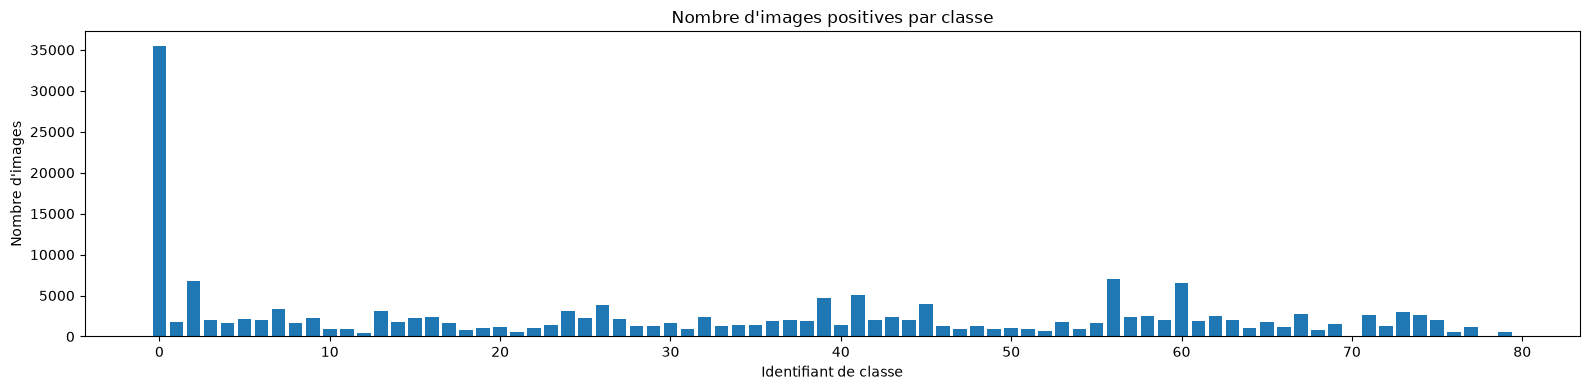

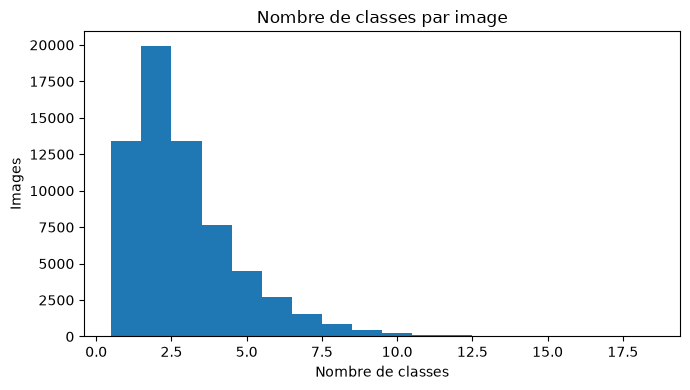

In [25]:
scan_files = label_files[:QUICK_MAX_IMAGES] if QUICK_RUN else label_files
class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
labels_per_image = []
invalid_rows = []

for p in tqdm(scan_files, desc="Annotations analysis"):
    try:
        ids = [int(x.strip()) for x in p.read_text().splitlines() if x.strip()]
        if any(i < 0 or i >= NUM_CLASSES for i in ids):
            invalid_rows.append(p.name)
            continue
        class_counts[np.unique(ids)] += 1
        labels_per_image.append(len(set(ids)))
    except Exception as e:
        print(f"Error processing {p.name}: {e}")
        invalid_rows.append(p.name)

print("Images analysed :", len(scan_files))
print("Annotations problematic :", len(invalid_rows))
print("Average number of classes/image :", round(float(np.mean(labels_per_image)), 3))
print("Median :", float(np.median(labels_per_image)))
print("Min / max :", min(labels_per_image), max(labels_per_image))

# Displaying the distribution of images per class in a DataFrame
freq_df = pd.DataFrame({"class": classes, "images_positives": class_counts})
display(freq_df.sort_values("images_positives"))

# Distribution of the number of images per class
plt.figure(figsize=(16, 4))
plt.bar(np.arange(NUM_CLASSES), class_counts)
plt.title("Nombre d'images positives par classe")
plt.xlabel("Identifiant de classe");
plt.ylabel("Nombre d'images")
plt.tight_layout();
plt.show()

# Distribution of the number of classes per image
plt.figure(figsize=(7, 4))
plt.hist(labels_per_image, bins=range(1, max(labels_per_image) + 2), align="left")
plt.title("Nombre de classes par image");
plt.xlabel("Nombre de classes");
plt.ylabel("Images")
plt.tight_layout();
plt.show()